# ⚽ FIFA World Cup Intelligence & Prediction System
## Phase 6: Match Outcome Prediction

**Notebook:** `06_match_prediction.ipynb`  
**Input:** `data/matches_prepared.csv`

---

### Objective

Build machine learning models to predict international football match outcomes — **Home Win, Draw, or Away Win** — using only pre-match information derived from historical data.


---
## Section 1: Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib
import os

print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('../data/matches_prepared.csv', parse_dates=['date'])

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns and types:')
print(df.dtypes)

Shape: 49,425 rows x 20 columns

Columns and types:
date                    datetime64[us]
home_team                          str
away_team                          str
home_score                     float64
away_score                     float64
tournament                         str
city                               str
country                            str
year                             int64
decade                           int64
total_goals                    float64
goal_difference                float64
goal_difference_abs            float64
match_result                       str
home_win                         int64
home_points                      int64
away_points                      int64
high_scoring_match                 str
goal_margin_category               str
is_neutral                       int64
dtype: object


In [3]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "home_team", "away_team", "match_result"])
df = df.sort_values("date").reset_index(drop=True)

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

Date range: 1872-11-30 to 2026-06-16


## 2. Historical Features

For every match, we calculate team statistics using only **earlier matches**.

This prevents data leakage.

For example, when predicting Brazil vs Germany in 2010, the Brazil statistics cannot include matches played after that 2010 match.

In [4]:
# Store previous match information for every team
team_history = {}

# Store previous meetings between pairs of teams
h2h_history = {}

feature_rows = []

for _, row in df.iterrows():
    home = row["home_team"]
    away = row["away_team"]

    home_hist = team_history.get(home, [])
    away_hist = team_history.get(away, [])

    # Overall historical statistics before the current match
    def win_rate(history):
        if not history:
            return 0.5
        return sum(x["win"] for x in history) / len(history)

    def avg_value(history, key):
        if not history:
            return 0.0
        return np.mean([x[key] for x in history])

    # Last 5 matches
    home_last5 = home_hist[-5:]
    away_last5 = away_hist[-5:]

    # Head-to-head from the current home team's perspective
    pair = (home, away)
    reverse_pair = (away, home)

    h2h = h2h_history.get(pair, [])
    reverse_h2h = h2h_history.get(reverse_pair, [])

    previous_h2h = h2h + [
        {"home_win": 0 if x["home_win"] == 1 else 1}
        for x in reverse_h2h
    ]

    if previous_h2h:
        h2h_home_win_rate = np.mean(
            [x["home_win"] for x in previous_h2h]
        )
    else:
        h2h_home_win_rate = 0.5

    features = {
        "home_team_win_rate": win_rate(home_hist),
        "away_team_win_rate": win_rate(away_hist),

        "home_team_avg_goals_scored": avg_value(home_hist, "goals_scored"),
        "away_team_avg_goals_scored": avg_value(away_hist, "goals_scored"),

        "home_team_avg_goals_conceded": avg_value(home_hist, "goals_conceded"),
        "away_team_avg_goals_conceded": avg_value(away_hist, "goals_conceded"),

        "home_team_last_5_win_rate": win_rate(home_last5),
        "away_team_last_5_win_rate": win_rate(away_last5),

        "home_team_last_5_avg_goals": avg_value(home_last5, "goals_scored"),
        "away_team_last_5_avg_goals": avg_value(away_last5, "goals_scored"),

        "head_to_head_home_win_rate": h2h_home_win_rate,

        "is_neutral": row["is_neutral"],
        "tournament": row["tournament"]
    }

    feature_rows.append(features)

    # IMPORTANT:
    # Current match information is added to history only AFTER
    # the prediction features have been created.
    home_result = row["match_result"]

    if home_result == "Home Team Win":
        home_win = 1
        away_win = 0
    elif home_result == "Away Team Win":
        home_win = 0
        away_win = 1
    else:
        home_win = 0
        away_win = 0

    home_entry = {
        "win": home_win,
        "goals_scored": row["home_score"],
        "goals_conceded": row["away_score"]
    }

    away_entry = {
        "win": away_win,
        "goals_scored": row["away_score"],
        "goals_conceded": row["home_score"]
    }

    team_history.setdefault(home, []).append(home_entry)
    team_history.setdefault(away, []).append(away_entry)

    h2h_history.setdefault(pair, []).append({
        "home_win": 1 if home_result == "Home Team Win" else 0
    })

historical_features = pd.DataFrame(feature_rows)

model_df = pd.concat(
    [
        df[["date", "home_team", "away_team", "match_result"]],
        historical_features
    ],
    axis=1
)

model_df.head()

,date,home_team,away_team,match_result,home_team_win_rate,away_team_win_rate,home_team_avg_goals_scored,away_team_avg_goals_scored,home_team_avg_goals_conceded,away_team_avg_goals_conceded,home_team_last_5_win_rate,away_team_last_5_win_rate,home_team_last_5_avg_goals,away_team_last_5_avg_goals,head_to_head_home_win_rate,is_neutral,tournament
0,1872-11-30,Scotland,England,Draw,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.500000,0,Friendly
1,1873-03-08,England,Scotland,Home Team Win,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0,Friendly
2,1874-03-07,Scotland,England,Home Team Win,0.000000,0.500000,1.000000,2.000000,2.000000,1.000000,0.000000,0.500000,1.000000,2.000000,0.000000,0,Friendly
3,1875-03-06,England,Scotland,Draw,0.333333,0.333333,1.666667,1.333333,1.333333,1.666667,0.333333,0.333333,1.666667,1.333333,0.666667,0,Friendly
4,1876-03-04,Scotland,England,Home Team Win,0.250000,0.250000,1.500000,1.750000,1.750000,1.500000,0.250000,0.250000,1.500000,1.750000,0.500000,0,Friendly


## 3. Check the Historical Features

The first matches for a team should have neutral/default historical values because there was not enough previous information.

This is expected.

Most importantly, the current match's score and result were **not** used to calculate its own features.

In [5]:
model_df[
    [
        "date",
        "home_team",
        "away_team",
        "home_team_win_rate",
        "away_team_win_rate",
        "home_team_last_5_win_rate",
        "away_team_last_5_win_rate",
        "head_to_head_home_win_rate",
        "match_result"
    ]
].head(10)

,date,home_team,away_team,home_team_win_rate,away_team_win_rate,home_team_last_5_win_rate,away_team_last_5_win_rate,head_to_head_home_win_rate,match_result
0,1872-11-30,Scotland,England,0.500000,0.500000,0.500000,0.500000,0.500000,Draw
1,1873-03-08,England,Scotland,0.000000,0.000000,0.000000,0.000000,1.000000,Home Team Win
2,1874-03-07,Scotland,England,0.000000,0.500000,0.000000,0.500000,0.000000,Home Team Win
3,1875-03-06,England,Scotland,0.333333,0.333333,0.333333,0.333333,0.666667,Draw
4,1876-03-04,Scotland,England,0.250000,0.250000,0.250000,0.250000,0.500000,Home Team Win
5,1876-03-25,Scotland,Wales,0.400000,0.500000,0.400000,0.500000,0.500000,Home Team Win
6,1877-03-03,England,Scotland,0.200000,0.500000,0.200000,0.600000,0.400000,Away Team Win
7,1877-03-05,Wales,Scotland,0.000000,0.571429,0.000000,0.800000,0.000000,Away Team Win
8,1878-03-02,Scotland,England,0.625000,0.166667,0.800000,0.200000,0.666667,Home Team Win
9,1878-03-23,Scotland,Wales,0.666667,0.000000,1.000000,0.000000,1.000000,Home Team Win


## 4. Select Model Features

We deliberately exclude current-match information such as:

- `home_score`
- `away_score`
- `total_goals`
- `goal_difference`
- `match_result`
- `home_win`
- `home_points`
- `away_points`

These describe the match outcome and would cause data leakage.

We also avoid using raw team names as direct model features. Instead, the model uses historical performance statistics.

In [6]:
feature_columns = [
    "home_team_win_rate",
    "away_team_win_rate",
    "home_team_avg_goals_scored",
    "away_team_avg_goals_scored",
    "home_team_avg_goals_conceded",
    "away_team_avg_goals_conceded",
    "home_team_last_5_win_rate",
    "away_team_last_5_win_rate",
    "home_team_last_5_avg_goals",
    "away_team_last_5_avg_goals",
    "head_to_head_home_win_rate",
    "is_neutral",
    "tournament"
]

X = model_df[feature_columns]
y = model_df["match_result"]

print("Features:")
print(feature_columns)
print("\nTarget distribution:")
print(y.value_counts())

Features:
['home_team_win_rate', 'away_team_win_rate', 'home_team_avg_goals_scored', 'away_team_avg_goals_scored', 'home_team_avg_goals_conceded', 'away_team_avg_goals_conceded', 'home_team_last_5_win_rate', 'away_team_last_5_win_rate', 'home_team_last_5_avg_goals', 'away_team_last_5_avg_goals', 'head_to_head_home_win_rate', 'is_neutral', 'tournament']

Target distribution:
match_result
Home Team Win    24222
Away Team Win    13962
Draw             11241
Name: count, dtype: int64


## 5. Chronological Train/Test Split

Football data is time-dependent, so a random train/test split is not appropriate here.

Instead:

- older matches → training data
- newer matches → test data

This better represents the real-world situation of predicting a future match using historical information.

In [7]:
split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training matches:", len(X_train))
print("Testing matches:", len(X_test))

print("\nTraining period:")
print(model_df.iloc[0]["date"].date(), "to", model_df.iloc[split_index - 1]["date"].date())

print("\nTesting period:")
print(model_df.iloc[split_index]["date"].date(), "to", model_df.iloc[-1]["date"].date())

Training matches: 39540
Testing matches: 9885

Training period:
1872-11-30 to 2016-03-25

Testing period:
2016-03-25 to 2026-06-16


## 6. Preprocessing

`tournament` is categorical, so it needs to be converted into numerical features.

We use one-hot encoding.

The encoder is fitted only on the training data through the scikit-learn pipeline, which prevents preprocessing leakage.

In [8]:

categorical_features = ["tournament"]
numeric_features = [col for col in feature_columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

## 7. Baseline Model

Before using machine learning models, we create a simple baseline.

The baseline always predicts the most common result in the training data.

A useful ML model should be compared against this baseline.

In [9]:

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, average="macro")

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline Macro F1:", round(baseline_f1, 4))

Baseline Accuracy: 0.4767
Baseline Macro F1: 0.2152


## 8. Logistic Regression

Logistic Regression provides a simple and interpretable classification model.

In [10]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred, average="macro")

print("Logistic Regression Accuracy:", round(logistic_accuracy, 4))
print("Logistic Regression Macro F1:", round(logistic_f1, 4))

Logistic Regression Accuracy: 0.5599
Logistic Regression Macro F1: 0.3987


## 9. Decision Tree

A Decision Tree can capture simple non-linear relationships between historical features and match outcomes.

In [11]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred, average="macro")

print("Decision Tree Accuracy:", round(tree_accuracy, 4))
print("Decision Tree Macro F1:", round(tree_f1, 4))

Decision Tree Accuracy: 0.5462
Decision Tree Macro F1: 0.3791


## 10. Random Forest

Random Forest combines multiple decision trees and is often a strong baseline for tabular data.

We will compare its actual performance with the other models rather than assuming it will be the best.

In [12]:
forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

forest_accuracy = accuracy_score(y_test, forest_pred)
forest_f1 = f1_score(y_test, forest_pred, average="macro")

print("Random Forest Accuracy:", round(forest_accuracy, 4))
print("Random Forest Macro F1:", round(forest_f1, 4))

Random Forest Accuracy: 0.5548
Random Forest Macro F1: 0.3823


## 11. Compare the Models

In [13]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Macro F1": [
        baseline_f1,
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

results = results.sort_values("Macro F1", ascending=False).reset_index(drop=True)

results.round(4)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.5599,0.3987
1,Random Forest,0.5548,0.3823
2,Decision Tree,0.5462,0.3791
3,Baseline,0.4767,0.2152


## 12. Detailed Evaluation of the Best Model

For the final model, we select the model with the highest **Macro F1**.

Macro F1 gives each outcome class equal importance, which is useful because Home Win, Draw and Away Win may not be equally common.

In [14]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

f1_scores = {
    "Logistic Regression": logistic_f1,
    "Decision Tree": tree_f1,
    "Random Forest": forest_f1
}

best_model_name = max(f1_scores, key=f1_scores.get)
best_model = models[best_model_name]

best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

Best model: Logistic Regression

Classification Report:
               precision    recall  f1-score   support

Away Team Win       0.56      0.45      0.50      2868
         Draw       0.19      0.00      0.00      2305
Home Team Win       0.56      0.90      0.69      4712

     accuracy                           0.56      9885
    macro avg       0.44      0.45      0.40      9885
 weighted avg       0.48      0.56      0.48      9885



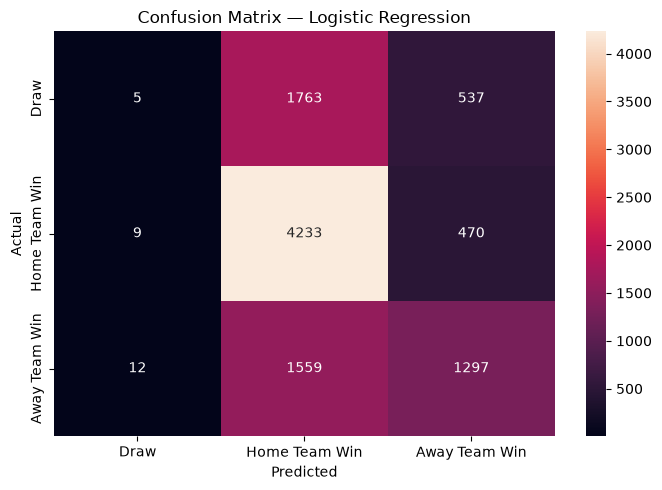

In [15]:
cm = confusion_matrix(y_test, best_predictions, labels=y.unique())

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=y.unique(),
    yticklabels=y.unique()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

## 14. Sample Predictions

The model can now predict outcomes for rows in the test period.

We also display predicted probabilities when the selected model supports them.

In [16]:
sample = X_test.head(10).copy()

sample_predictions = best_model.predict(sample)

prediction_output = model_df.loc[
    X_test.head(10).index,
    ["date", "home_team", "away_team", "match_result"]
].copy()

prediction_output["predicted_result"] = sample_predictions

if hasattr(best_model, "predict_proba"):
    probabilities = best_model.predict_proba(sample)
    classes = best_model.named_steps["model"].classes_

    probability_df = pd.DataFrame(
        probabilities,
        columns=[f"prob_{c}" for c in classes],
        index=sample.index
    )

    prediction_output = pd.concat(
        [prediction_output.reset_index(drop=True),
         probability_df.reset_index(drop=True)],
        axis=1
    )

prediction_output

,date,home_team,away_team,match_result,predicted_result,prob_Away Team Win,prob_Draw,prob_Home Team Win
0,2016-03-25,Guatemala,United States,Home Team Win,Home Team Win,0.341965,0.262280,0.395755
1,2016-03-25,Republic of Ireland,Switzerland,Home Team Win,Home Team Win,0.195049,0.282984,0.521967
2,2016-03-25,Algeria,Ethiopia,Home Team Win,Home Team Win,0.079181,0.193052,0.727767
3,2016-03-25,Armenia,Belarus,Draw,Away Team Win,0.405863,0.296207,0.297930
4,2016-03-25,Brazil,Uruguay,Draw,Home Team Win,0.139554,0.219356,0.641089
5,2016-03-25,Canada,Mexico,Away Team Win,Away Team Win,0.427248,0.282390,0.290362
6,2016-03-25,Ivory Coast,Sudan,Home Team Win,Home Team Win,0.060899,0.194346,0.744755
7,2016-03-25,Gabon,Sierra Leone,Home Team Win,Home Team Win,0.181229,0.283355,0.535416
8,2016-03-25,Guinea,Malawi,Draw,Home Team Win,0.109497,0.238540,0.651964
9,2016-03-25,Haiti,Panama,Draw,Home Team Win,0.164640,0.227952,0.607409


## 15. Save the Best Model

In [17]:
os.makedirs("../models", exist_ok=True)

model_path = "../models/match_prediction_model.pkl"

joblib.dump(best_model, model_path)

print("Saved model:", model_path)

Saved model: ../models/match_prediction_model.pkl


In [18]:
# Test that the saved model can be loaded

loaded_model = joblib.load(model_path)

test_prediction = loaded_model.predict(X_test.head(1))

print("Loaded model successfully.")
print("Example prediction:", test_prediction[0])

Loaded model successfully.
Example prediction: Home Team Win
